<a href="https://colab.research.google.com/github/96rodrigues/Extra-o-da-Linha-de-Costa/blob/main/Extra%C3%A7%C3%A3o_da_linha_de_costa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install rasterio geopandas shapely scikit-image -q

In [20]:
import os
import re
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from skimage import measure
from shapely.geometry import LineString
import geopandas as gpd

In [22]:
from google.colab import drive
drive.mount('/content/drive')
pasta= '/content/drive/MyDrive/GEE_IGUAPE'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import os

GREEN = 3
SWIR = 11
# LIMIAR DO MNDWI PARA SEPARAR ÁGUA DE TERRA
LIMIAR = 0.0

# pasta com as imagens .tif de entrada
PASTA_ENTRADA = '/content/drive/MyDrive/GEE_IGUAPE'  # ajuste conforme necessário

CAMINHO_AREA='/content/drive/MyDrive/GEE_IGUAPE/area.shp'
# pasta de saída dos resultados
SAIDA = '/content/drive/MyDrive/GEE_IGUAPE'
os.makedirs(SAIDA, exist_ok=True)

Processando: img_2023.tif
Processando: img_2024.tif
Processando: img_2025.tif
Linhas antes do recorte: 3 | depois do recorte: 3
Linhas de costa salvas em: /content/drive/MyDrive/GEE_IGUAPE/linhas_costa.geojson


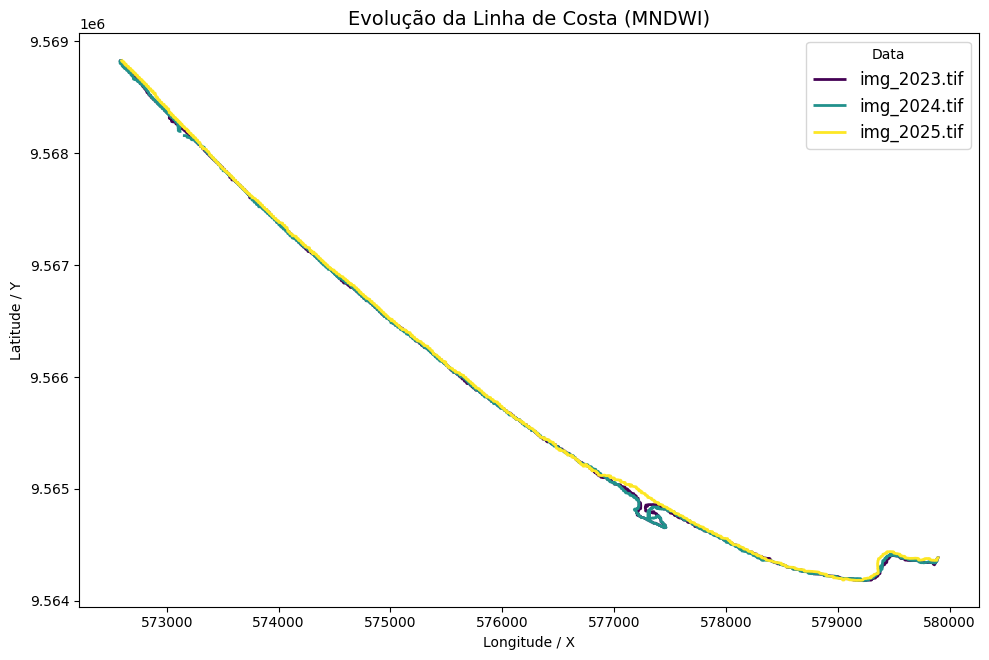

Mapa salvo em: /content/drive/MyDrive/GEE_IGUAPE/mapa_linhas_costa.png


In [24]:
def calcular_mndwi(caminho, GREEN, SWIR):
    with rasterio.open(caminho) as src:
        green = src.read(GREEN).astype('float32')
        swir = src.read(SWIR).astype('float32')
        transform = src.transform
        crs = src.crs

    np.seterr(divide='ignore', invalid='ignore')
    mndwi = (green - swir) / (green + swir)
    mndwi = np.nan_to_num(mndwi, nan=-1.0, posinf=1.0, neginf=-1.0)
    return mndwi, transform, crs


def extrair_LC(mndwi, LIMIAR, transform):
    contornos = measure.find_contours(mndwi, level=LIMIAR)

    linhas_geo = []
    for contorno in contornos:
        coords_geo = []
        for row, col in contorno:
            x, y = rasterio.transform.xy(transform, row, col)
            coords_geo.append((x, y))
        if len(coords_geo) > 1:
            linhas_geo.append(LineString(coords_geo))
    return linhas_geo


def extrair_data_do_nome(nome_arquivo):
    m = re.search(r'(\d{4})[-_]?\d{2}[-_]?\d{2}', nome_arquivo)
    return m.group(1) if m else nome_arquivo


def processar_imagens(pasta, GREEN, SWIR, LIMIAR):
    arquivos = sorted(glob.glob(os.path.join(pasta, '*.tif')))
    if not arquivos:
        raise FileNotFoundError(f'Nenhum arquivo .tif encontrado em {pasta}')

    registros = []
    crs_referencia = None

    for caminho in arquivos:
        nome = os.path.basename(caminho)
        print(f'Processando: {nome}')

        mndwi, transform, crs = calcular_mndwi(caminho, GREEN, SWIR)

        if crs_referencia is None:
            crs_referencia = crs

        linhas = extrair_LC(mndwi, LIMIAR, transform)

        if linhas:
            linha_principal = max(linhas, key=lambda l: l.length)
            data_str = extrair_data_do_nome(nome)
            registros.append({'arquivo': nome, 'data': data_str, 'geometry': linha_principal})
        else:
            print(f'Nenhuma linha de costa encontrada em {nome}')

    gdf = gpd.GeoDataFrame(registros, crs=crs_referencia)
    return gdf



def recortar_com_area_estudo(gdf_linhas, caminho_shp):
    """Recorta as linhas de costa usando o shapefile da área de estudo.
    Reprojeta automaticamente o shapefile para o CRS das linhas, se necessário."""
    area = gpd.read_file(caminho_shp)

    if area.crs is None:
        raise ValueError(
            'O shapefile da área de estudo não possui CRS definido. '
            'Verifique se o arquivo .prj está presente na mesma pasta do .shp.'
        )

    if area.crs != gdf_linhas.crs:
        print(f'Reprojetando área de estudo de {area.crs} para {gdf_linhas.crs}...')
        area = area.to_crs(gdf_linhas.crs)

    gdf_recortado = gpd.clip(gdf_linhas, area)

    # remove geometrias vazias que podem sobrar do recorte
    gdf_recortado = gdf_recortado[~gdf_recortado.geometry.is_empty]
    gdf_recortado = gdf_recortado[gdf_recortado.geometry.notnull()]

    print(f'Linhas antes do recorte: {len(gdf_linhas)} | depois do recorte: {len(gdf_recortado)}')
    return gdf_recortado

def plotar_mapa(gdf, caminho_saida, area_estudo=None):
    """Plota todas as linhas de costa extraídas em um único mapa,
    coloridas de acordo com a data, e salva como imagem."""
    fig, ax = plt.subplots(figsize=(10, 10))

    if area_estudo is not None:
        area_estudo.boundary.plot(ax=ax, color='gray', linewidth=1, linestyle='--', label='Área de estudo')

    cores = cm.viridis(np.linspace(0, 1, max(len(gdf), 1)))

    for cor, (_, row) in zip(cores, gdf.iterrows()):
        gpd.GeoSeries([row.geometry], crs=gdf.crs).plot(
            ax=ax, color=cor, linewidth=2, label=row['data']
        )

    ax.set_title('Evolução da Linha de Costa (MNDWI)', fontsize=14)
    ax.set_xlabel('Longitude / X')
    ax.set_ylabel('Latitude / Y')
    ax.legend(title='Data', loc='best', fontsize=12)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.savefig(caminho_saida, dpi=400)
    plt.show()
    print(f'Mapa salvo em: {caminho_saida}')

gdf_linhas = processar_imagens(PASTA_ENTRADA, GREEN, SWIR, LIMIAR)

gdf_linhas = recortar_com_area_estudo(gdf_linhas, CAMINHO_AREA)


caminho_geojson = os.path.join(SAIDA, 'linhas_costa.geojson')
gdf_linhas.to_file(caminho_geojson, driver='GeoJSON')
print(f'Linhas de costa salvas em: {caminho_geojson}')

caminho_mapa = os.path.join(SAIDA, 'mapa_linhas_costa.png')
plotar_mapa(gdf_linhas, caminho_mapa)

